<a href="https://colab.research.google.com/github/powerfulsmooth/DeepONet_Pytorch_Demo/blob/main/transformer_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [255]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn
seaborn.set_context(context="talk")
%matplotlib inline

In [256]:
class EncoderDecoder (nn.Module):
  def __init__(self, encoder,decoder, src_embed, tgt_embed, generator):
    super(EncoderDecoder, self).__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.src_embed = src_embed
    self.tgt_embed = tgt_embed
    self.generator = generator

  def forward (self, src, tgt, src_mask, tgt_mask):
    return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

  def encode (self, src, src_mask):
    return self.encoder(self.src_embed(src), src_mask)

  def decode (self, memory, src_mask, tgt, tgt_mask):
    return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [257]:
class Generator(nn.Module):

  def __init__(self, d_model, vocab):
    super(Generator, self).__init__()
    self.proj = nn.Linear(d_model, vocab)

  def forward (self, x):
    return F.log_softmax(self.proj(x), dim=-1)

In [258]:
def clones(module, N):
  return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [259]:
class Encoder(nn.Module):

  def __init__(self, layer, N):
      super(Encoder, self).__init__()
      self.layers = clones(layer, N)
      self.norm = LayerNorm(layer.size)

  def forward(self, x, mask):
      for layer in self.layers:
          x = layer(x, mask)
      return self.norm(x)

In [260]:
class LayerNorm(nn.Module):

    def __init__ (self, features, eps =1e-6):
        super().__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward (self,x):
      mean = x.mean(-1, keepdim=True)
      std = x.std(-1, keepdim=True)
      return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

In [261]:
class SublayerConnection(nn.Module):


    def __init__ (self, size, dropout):
        super().__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

In [262]:
class EncoderLayer(nn.Module):

    def __init__ (self, size, self_attn, feed_forward, dropout):
        super().__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout),2)
        self.size = size

    def forward (self, x, mask):
        x = self.sublayer[0](x, lambda x: self.self_attn(x,x,x,mask))
        return self.sublayer[1](x, self.feed_forward)

In [263]:
class Decoder(nn.Module):
    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)   # ← 이게 있어야 함
    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)                 # ← 여기서 self.norm을 부름

In [264]:
def subsequent_mask(size):

    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(
        torch.uint8)


    return subsequent_mask == 0


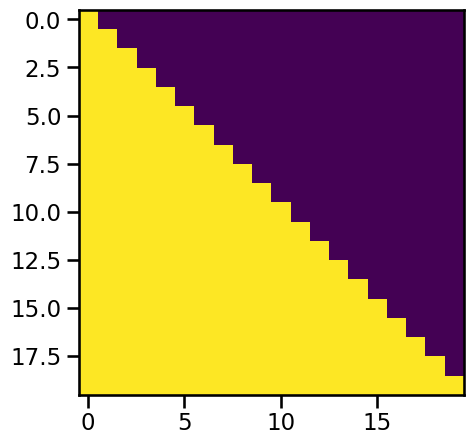

In [265]:
plt.figure(figsize=(5,5))
plt.imshow(subsequent_mask(20)[0])

In [266]:
def attention (query, key, value, mask=None, dropout=None):

    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2,-1))/math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

In [267]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super().__init__()
        assert d_model % h == 0

        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)


    def forward(self, query, key, value, mask=None):

        if mask is not None:
            mask = mask.unsqueeze(1)

        nbatches = query.size(0)

        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1,2)
            for lin, x in zip(self.linears, (query, key, value))
        ]

        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout

        )

        x = (
            x.transpose(1,2)
            .contiguous()
            .view(nbatches, -1, self.h * self.d_k)
        )

        del query
        del key
        del value
        return self.linears[-1](x)

In [268]:
class PositionwiseFeedForward(nn.Module):

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(self.w_1(x).relu()))

In [269]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super().__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

In [270]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)


    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

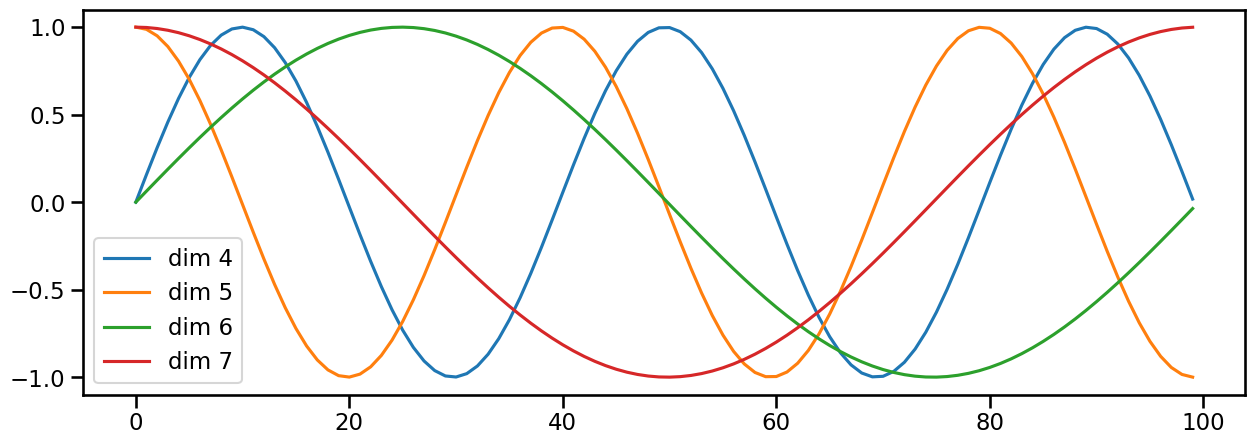

In [271]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])

In [272]:
def make_model(
    src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1
):

    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

In [273]:
class Batch:
    """Object for holding a batch of data with mask during training."""

    def __init__(self, src, tgt=None, pad=2):  # 2 = <blank>
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(
            tgt_mask.data
        )
        return tgt_mask

In [274]:
def run_epoch(data_iter, model, loss_compute):
    "Standard Training and Logging Function"
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    for i, batch in enumerate(data_iter):
        out = model.forward(batch.src, batch.tgt,
                            batch.src_mask, batch.tgt_mask)
        loss = loss_compute(out, batch.tgt_y, batch.ntokens)
        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens
        if i % 50 == 1:
            elapsed = time.time() - start
            print("Epoch Step: %d Loss: %f Tokens per Sec: %f" %
                    (i, loss / batch.ntokens, tokens / elapsed))
            start = time.time()
            tokens = 0
    return total_loss / total_tokens

In [275]:
class NoamOpt:
    "Optim wrapper that implements rate."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0

    def step(self):
        "Update parameters and rate"
        self._step += 1
        rate = self.rate()
        for p in self.optimizer.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()

    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step
        return self.factor * \
            (self.model_size ** (-0.5) *
            min(step ** (-0.5), step * self.warmup ** (-1.5)))

def get_std_opt(model):
    return NoamOpt(model.src_embed[0].d_model, 2, 4000,
            torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

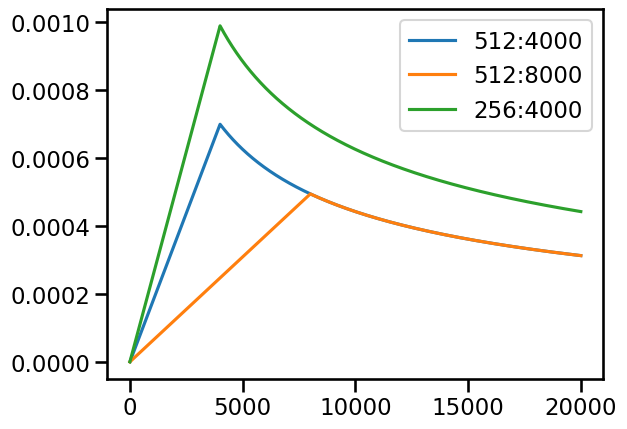

In [276]:
# Three settings of the lrate hyperparameters.
opts = [NoamOpt(512, 1, 4000, None),
        NoamOpt(512, 1, 8000, None),
        NoamOpt(256, 1, 4000, None)]
plt.plot(np.arange(1, 20000), [[opt.rate(i) for opt in opts] for i in range(1, 20000)])
plt.legend(["512:4000", "512:8000", "256:4000"])

In [277]:
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

In [278]:
class LabelSmoothing(nn.Module):
    "Implement label smoothing."

    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.clone().detach())

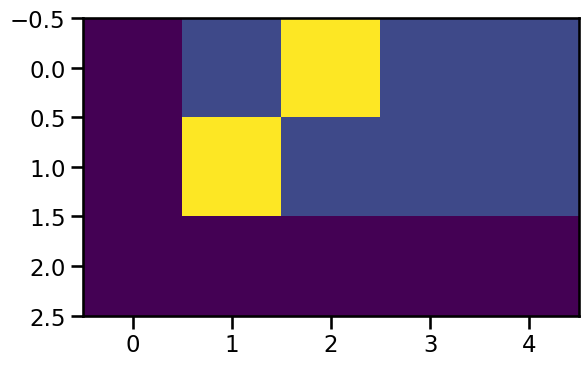

In [279]:
# Example of label smoothing.
crit = LabelSmoothing(5, 0, 0.4)
predict = torch.FloatTensor([[0, 0.2, 0.7, 0.1, 0],
                             [0, 0.2, 0.7, 0.1, 0],
                             [0, 0.2, 0.7, 0.1, 0]])
v = crit(Variable(predict.log()),
         Variable(torch.LongTensor([2, 1, 0])))

# Show the target distributions expected by the system.
plt.imshow(crit.true_dist)

In [280]:
def loss(x, crit):
    d = x + 3 * 1
    predict = torch.FloatTensor([[0, x / d, 1 / d, 1 / d, 1 / d]])
    return crit(predict.log(), torch.LongTensor([1])).data

In [281]:
def data_gen(V, batch, nbatches):
    "Generate random data for a src-tgt copy task."
    for i in range(nbatches):
        data = torch.from_numpy(np.random.randint(1, V, size=(batch, 10)))
        data[:, 0] = 1
        src = Variable(data, requires_grad=False)
        tgt = Variable(data, requires_grad=False)
        yield Batch(src, tgt, 0)

In [282]:
gener = data_gen(11, 30, 20)

for i, batch in enumerate(gener):
    print("Source:")
    print(batch.src.shape)
    print("Target:")
    print(batch.tgt.shape)
    # batch.src_mask, batch.tgt_mask
    print(batch.src_mask)
    print(batch.tgt_mask)
    # 필요한 경우 특정 배치까지만 확인
    if i == 0:  # 첫 번째 배치만 확인
        break

Source:
torch.Size([30, 10])
Target:
torch.Size([30, 9])
tensor([[[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, True]],

        [[True, True, True, True, True, True, True, True, True, Tru

In [283]:
class SimpleLossCompute:

    def __init__(self, generator, criterion, opt=None):
        self.generator = generator
        self.criterion = criterion
        self.opt = opt

    def __call__(self, x, y, norm):
        x = self.generator(x)
        loss = self.criterion(x.contiguous().view(-1, x.size(-1)),
                              y.contiguous().view(-1)) / norm
        loss.backward()
        if self.opt is not None:
            self.opt.step()
            self.opt.optimizer.zero_grad()
        return loss.data * norm

In [284]:
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

In [285]:
# Train the simple copy task.
V = 11
criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)
model = make_model(V, V, N=2)
model_opt = NoamOpt(model.src_embed[0].d_model, 1, 400,
        torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

for epoch in range(10):
    model.train()
    run_epoch(data_gen(V, 30, 20), model, SimpleLossCompute(model.generator, criterion, model_opt))
    model.eval()
    print(run_epoch(data_gen(V, 30, 5), model,
                    SimpleLossCompute(model.generator, criterion, None)))

Epoch Step: 1 Loss: 3.212837 Tokens per Sec: 482.702606
Epoch Step: 1 Loss: 1.971304 Tokens per Sec: 853.179016
tensor(1.9860)
Epoch Step: 1 Loss: 1.982709 Tokens per Sec: 613.717896
Epoch Step: 1 Loss: 1.589705 Tokens per Sec: 630.740295
tensor(1.6456)
Epoch Step: 1 Loss: 1.873485 Tokens per Sec: 532.595276
Epoch Step: 1 Loss: 1.500330 Tokens per Sec: 875.497803
tensor(1.4690)
Epoch Step: 1 Loss: 1.740057 Tokens per Sec: 477.615875
Epoch Step: 1 Loss: 1.198967 Tokens per Sec: 816.501099
tensor(1.2220)
Epoch Step: 1 Loss: 1.433287 Tokens per Sec: 618.585327
Epoch Step: 1 Loss: 1.072567 Tokens per Sec: 816.487549
tensor(1.1017)
Epoch Step: 1 Loss: 1.303030 Tokens per Sec: 623.884338
Epoch Step: 1 Loss: 0.658197 Tokens per Sec: 855.364929
tensor(0.7289)
Epoch Step: 1 Loss: 0.766875 Tokens per Sec: 613.378174
Epoch Step: 1 Loss: 0.410295 Tokens per Sec: 862.626831
tensor(0.3638)
Epoch Step: 1 Loss: 0.841796 Tokens per Sec: 615.790283
Epoch Step: 1 Loss: 0.347728 Tokens per Sec: 626.372314

In [286]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type_as(src.data)
    for i in range(max_len-1):
        out = model.decode(memory, src_mask,
                           Variable(ys),
                           Variable(subsequent_mask(ys.size(1))
                                    .type_as(src.data)))
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim = 1)
        next_word = next_word.data[0]
        ys = torch.cat([ys,
                        torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=1)
    return ys

model.eval()
src = Variable(torch.LongTensor([[1,2,3,4,5,6,7,8,9,10]]) )
src_mask = Variable(torch.ones(1, 1, 10) )
print(greedy_decode(model, src, src_mask, max_len=10, start_symbol=1))

tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])
